In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [34]:
def make_spirals(n_samples=500, noise=0.1, random_state=2137):
    """ Generuje dane w ksztalcie spiral ."""
    np.random.seed(random_state)
    n = n_samples // 2
    theta = np.linspace(0, 4*np.pi, n)
    r = theta / (4 * np.pi)
    x1 = r * np.cos(theta) + noise * np.random.randn(n)
    y1 = r * np.sin(theta) + noise * np.random.randn(n)
    x2 = -r * np.cos(theta) + noise * np.random.randn(n)
    y2 = -r * np.sin(theta) + noise * np.random.randn (n)
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2 , y2])])
    y = np.array ([0]*n + [1]*n)
    return X , y

In [35]:
def plot_decision_boundary(model, X, y, ax, title=""):
    """Rysuje granice decyzyjną modelu."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    if hasattr(model, "decision_function"):
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = (Z > 0).astype(int) # Dla SVM binaryzujemy do wizualizacji klas
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=20)
    ax.set_title(title)

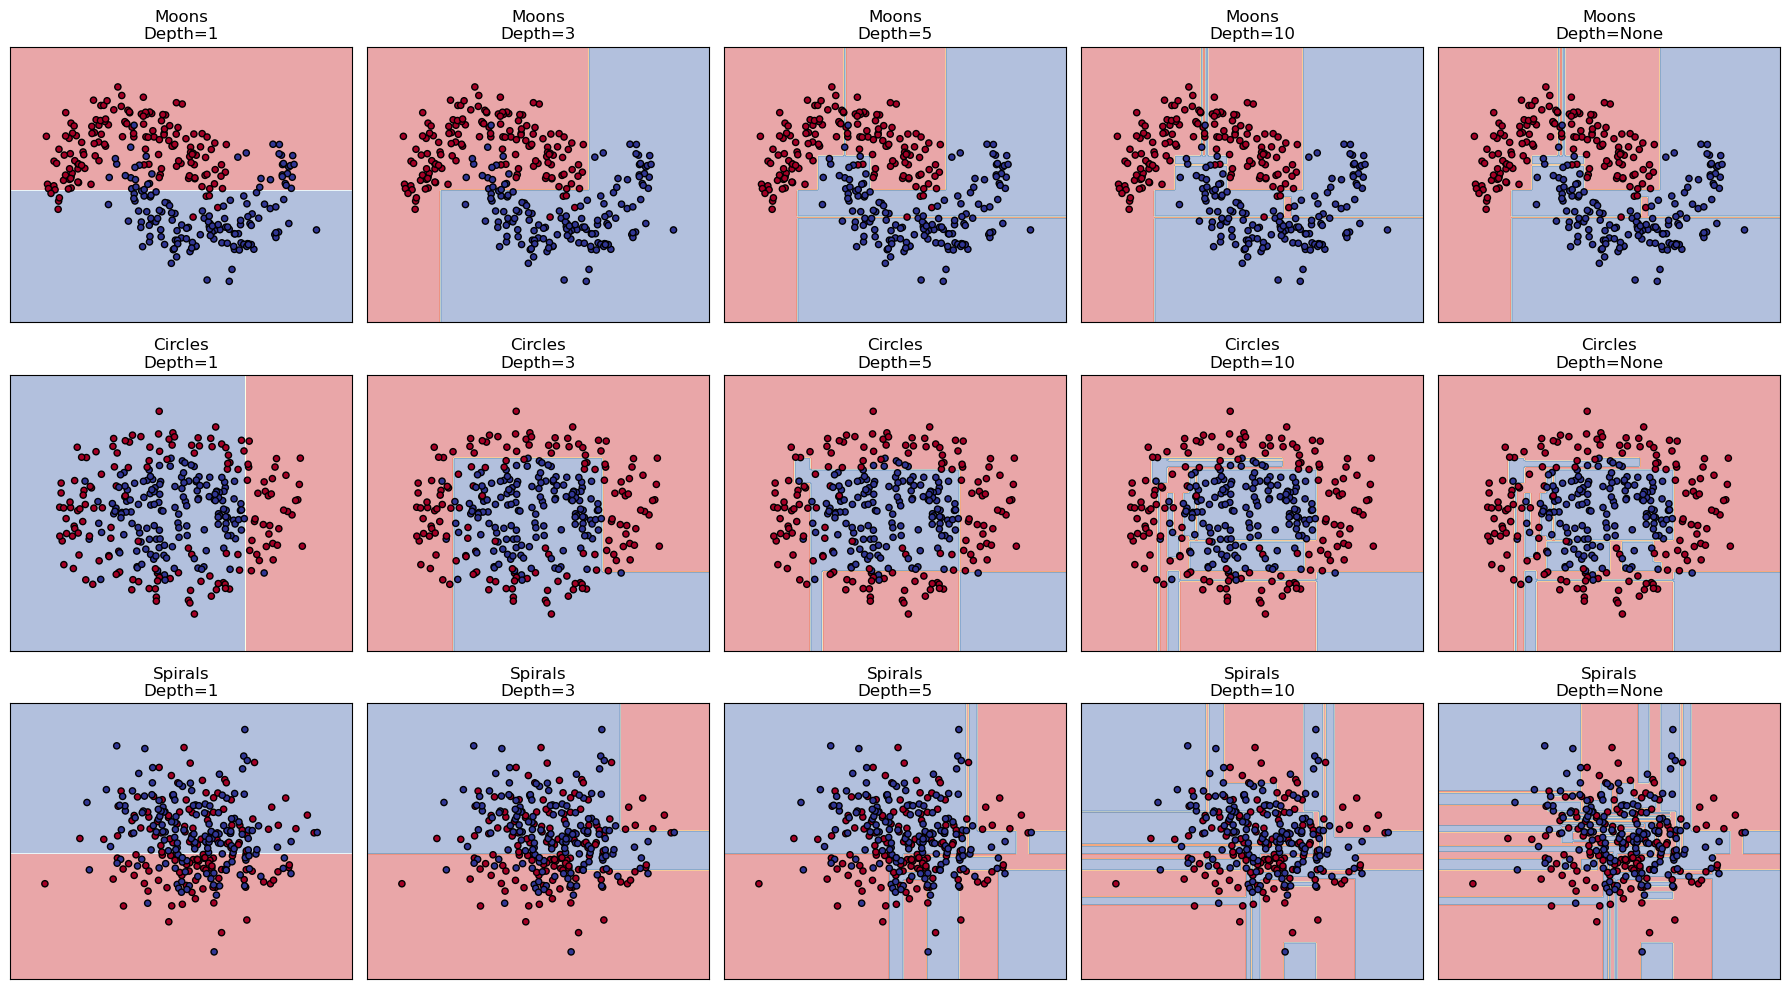

In [36]:
datasets = [
    make_moons(n_samples=300, noise=0.2, random_state=2137),
    make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=2137),
    make_spirals(n_samples=300, noise=0.5, random_state=2137)
]
dataset_names = ["Moons", "Circles", "Spirals"]
depths = [1, 3, 5, 10, None]

fig, axes = plt.subplots(len(datasets), len(depths), figsize=(18, 10))

for i, (X, y) in enumerate(datasets):
    for j, depth in enumerate(depths):
        ax = axes[i, j]
        clf = DecisionTreeClassifier(max_depth=depth, random_state=2137)
        clf.fit(X, y)
        
        depth_str = f"Depth={depth}" if depth else "Depth=None"
        plot_decision_boundary(clf, X, y, ax, title=f"{dataset_names[i]}\n{depth_str}")
        ax.set_xticks(())
        ax.set_yticks(())

plt.tight_layout()
plt.show()

Drzewa nie potrafią rysować łuków. Przybliżają je kawałkami porsotkątów, i to jeszcze z bokami równoległymi do osi. Tutaj głębokoś absolutnie pogarsza gładkość, granice są coraz bardziej poszatkowane.

B - Na księżycach

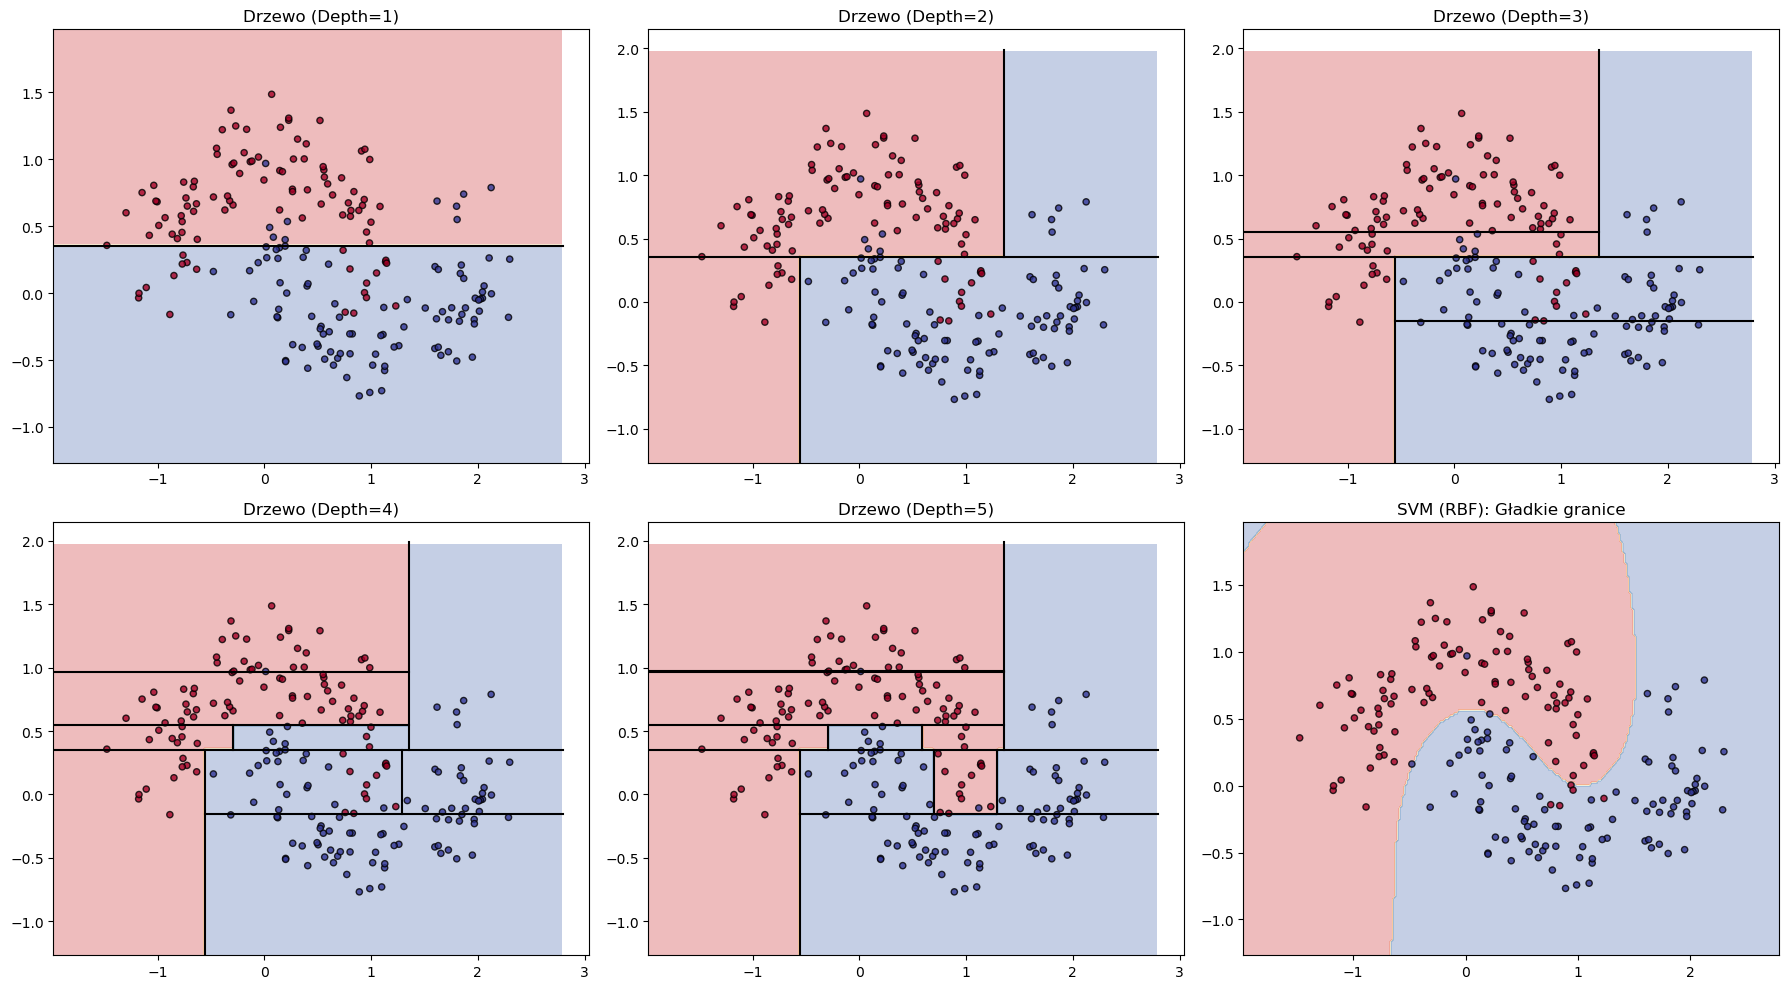

In [37]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

def plot_decision_boundary(model, X, y, ax, title=""):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    if hasattr(model, "decision_function"):
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = (Z > 0).astype(int)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=20, alpha=0.8)
    ax.set_title(title)
    return x_min, x_max, y_min, y_max

def plot_tree_splits(tree_struct, node_id, x_min, x_max, y_min, y_max, ax):
    """
    Rekurencyjnie rysuje czarne linie podziałów (boxy) na zadanym wykresie (ax).
    """
    if tree_struct.children_left[node_id] == -1:
        return

    feature = tree_struct.feature[node_id]
    threshold = tree_struct.threshold[node_id]

    # Rysujemy linię
    if feature == 0: # Podział na osi X (pionowa linia)
        # Rysujemy kreskę od y_min do y_max w punkcie x=threshold
        ax.plot([threshold, threshold], [y_min, y_max], 'k-', lw=1.5)
        
        plot_tree_splits(tree_struct, tree_struct.children_left[node_id], 
                         x_min, threshold, y_min, y_max, ax)
        plot_tree_splits(tree_struct, tree_struct.children_right[node_id], 
                         threshold, x_max, y_min, y_max, ax)
        
    else: # Podział na osi Y (pozioma linia)
        # Rysujemy kreskę od x_min do x_max w punkcie y=threshold
        ax.plot([x_min, x_max], [threshold, threshold], 'k-', lw=1.5)
        
        plot_tree_splits(tree_struct, tree_struct.children_left[node_id], 
                         x_min, x_max, y_min, threshold, ax)
        plot_tree_splits(tree_struct, tree_struct.children_right[node_id], 
                         x_min, x_max, threshold, y_max, ax)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

depths = [1, 2, 3, 4, 5]

# A) Rysujemy drzewa dla kolejnych głębokości
for i, depth in enumerate(depths):
    ax = axes[i]
    
    # 1. Trenujemy drzewo o zadanej głębokości
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X, y)
    
    # 2. Rysujemy tło (granice decyzyjne)
    x_min, x_max, y_min, y_max = plot_decision_boundary(clf, X, y, ax, title=f"Drzewo (Depth={depth})")
    
    # 3. Nakładamy czarne linie podziałów (struktura drzewa)
    plot_tree_splits(clf.tree_, 0, x_min, x_max, y_min, y_max, ax)

# SVM dla porównania
ax_svm = axes[5]
svm_clf = SVC(kernel='rbf', C=1, gamma=1)
svm_clf.fit(X, y)
plot_decision_boundary(svm_clf, X, y, ax_svm, title="SVM (RBF): Gładkie granice")

plt.tight_layout()
plt.show()

Liczba punktów w siatce: 90000
Trenowanie drzew...


/tmp/ipykernel_3542/713359189.py:30: RuntimeWarning: divide by zero encountered in log10
  slope, intercept, _, _, _ = linregress(np.log10(errors), np.log10(leaves))
/home/wiktor/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2842: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/tmp/ipykernel_3542/713359189.py:37: RuntimeWarning: divide by zero encountered in divide
  ref_leaves = C / errors


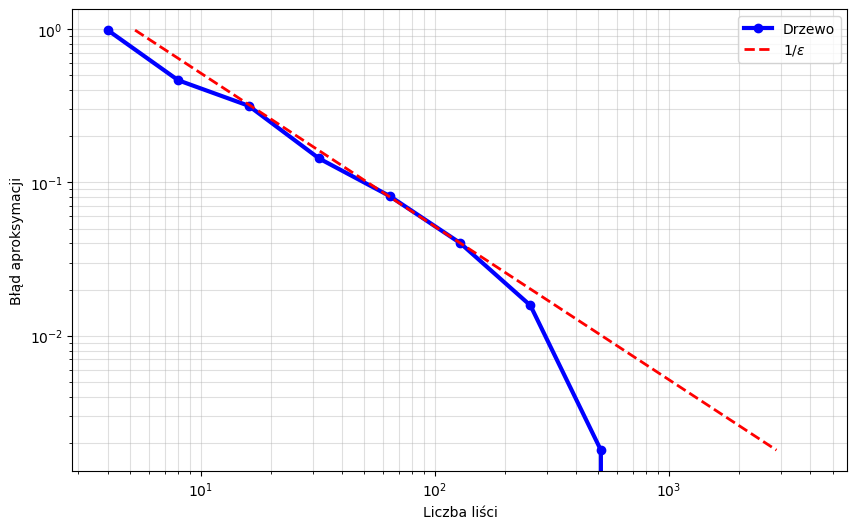

In [38]:
from scipy.stats import linregress

def count_splits_for_circle():
    res = 0.008 
    xx, yy = np.meshgrid(np.arange(-1.2, 1.2, res), np.arange(-1.2, 1.2, res))
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    
    y_grid = (X_grid[:, 0]**2 + X_grid[:, 1]**2 <= 1.0).astype(int)
    
    leaf_counts = [2 ** i for i in range(2, 13)] 
    errors = []

    print(f"Liczba punktów w siatce: {len(y_grid)}")
    print("Trenowanie drzew...")
    
    for max_leaves in leaf_counts:
        clf = DecisionTreeClassifier(max_leaf_nodes=max_leaves, random_state=42)
        clf.fit(X_grid, y_grid)
        
        y_pred = clf.predict(X_grid)
        
        # Błąd to pole powierzchni
        error_area = np.sum(y_pred != y_grid) * (res**2)
        errors.append(error_area)

    return np.array(leaf_counts), np.array(errors)

leaves, errors = count_splits_for_circle()

slope, intercept, _, _, _ = linregress(np.log10(errors), np.log10(leaves))

plt.figure(figsize=(10, 6))

plt.plot(leaves, errors, 'o-', linewidth=3, label='Drzewo', color='blue')

C = leaves[len(leaves)//2] * errors[len(errors)//2] 
ref_leaves = C / errors
plt.plot(ref_leaves, errors, '--', color='red', label=r'$1/\epsilon$', linewidth=2)

plt.ylabel("Błąd aproksymacji")
plt.xlabel("Liczba liści")

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()

# Odwracamy oś X, bo chcemy widzieć spadek błędu w prawą stronę
# plt.gca().invert_xaxis() 

plt.show()

Kosz aproksymacji okręgu za pomocą drzewa decyzyjnego wydaje się być rzędu $\frac{1}{\epsilon}$ albo gorzej.

Oznacza, to że drzewa muszą być naprawdę spore a cała metoda staje się niefektywana.

In [39]:
class SimpleObliqueNode:
    def __init__(self, max_depth, depth=0, n_attempts=20):
        self.max_depth = max_depth
        self.depth = depth
        self.n_attempts = n_attempts
        self.weights = None
        self.threshold = None
        self.left_child = None
        self.right_child = None
        self.leaf_value = None

    def fit(self, X, y):
        if self.depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < 2:
            self.leaf_value = int(np.round(np.mean(y)))
            return

        best_score = -1
        best_weights = None
        best_threshold = None
        
        # próbujemy rózne współczynniki
        for _ in range(self.n_attempts):
            current_weights = np.random.randn(X.shape[1])
            X_projected = X.dot(current_weights).reshape(-1, 1)
            
            # tutaj max_depth=1!!!!
            clf = DecisionTreeClassifier(max_depth=1, random_state=2137)
            clf.fit(X_projected, y)
            score = clf.score(X_projected, y)
            
            if score > best_score:
                best_score = score
                best_weights = current_weights
                best_threshold = clf.tree_.threshold[0]

        self.weights = best_weights
        self.threshold = best_threshold
        
        projection = X.dot(self.weights)
        left_mask = projection <= self.threshold
        
        if len(y[left_mask]) == 0 or len(y[~left_mask]) == 0:
            self.leaf_value = int(np.round(np.mean(y)))
            return

        self.left_child = SimpleObliqueNode(self.max_depth, self.depth + 1, self.n_attempts)
        self.left_child.fit(X[left_mask], y[left_mask])
        
        self.right_child = SimpleObliqueNode(self.max_depth, self.depth + 1, self.n_attempts)
        self.right_child.fit(X[~left_mask], y[~left_mask])

    def predict_one(self, x):
        if self.leaf_value is not None:
            return self.leaf_value
        val = np.dot(x, self.weights)
        if val <= self.threshold:
            return self.left_child.predict_one(x)
        else:
            return self.right_child.predict_one(x)

class ObliqueDecisionTree:
    def __init__(self, max_depth=3, n_attempts=20):
        self.max_depth = max_depth
        self.n_attempts = n_attempts
        self.root = None
    
    def fit(self, X, y):
        self.root = SimpleObliqueNode(self.max_depth, n_attempts=self.n_attempts)
        self.root.fit(X, y)
        return self
    
    def predict(self, X):
        return np.array([self.root.predict_one(x) for x in X])

In [40]:
def plot_boundary(model, X, y, ax, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(title)

Dataset    | Model           | Czas [s]  
----------------------------------------
Moons      | Standard        | 0.0017
Moons      | Oblique         | 0.1045
Circles    | Standard        | 0.0007
Circles    | Oblique         | 0.0756
Spirals    | Standard        | 0.0011
Spirals    | Oblique         | 0.6990


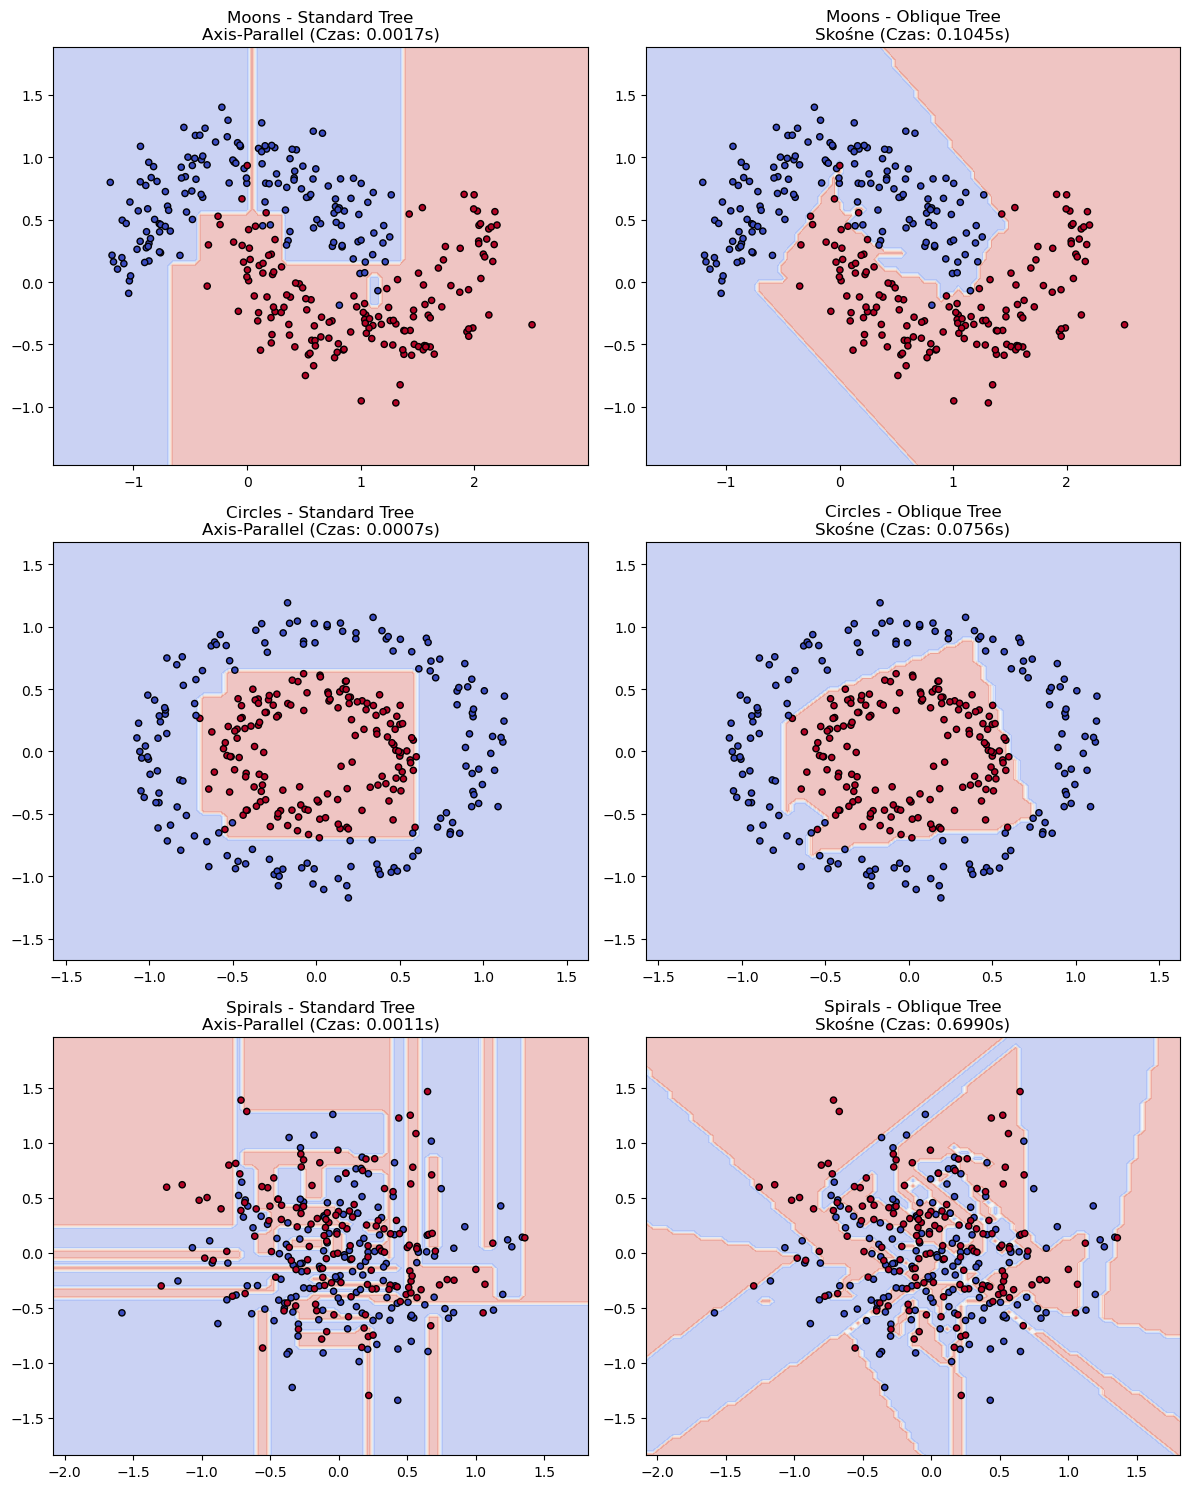

In [ ]:
import time

datasets = [
    make_moons(n_samples=300, noise=0.2, random_state=2137),
    make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=2137),
    make_spirals(n_samples=300, noise=0.3, random_state=2137) 
]
dataset_names = ["Moons", "Circles", "Spirals"]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

print(f"{'Dataset':<10} | {'Model':<15} | {'Czas [s]':<10}")
print("-" * 40)

for i, (X, y) in enumerate(datasets):
    name = dataset_names[i]
    
    # --- 1. Standardowe Drzewo ---
    start_time = time.time()
    
    std_tree = DecisionTreeClassifier(max_depth=25, random_state=2137)
    std_tree.fit(X, y)
    
    std_time = time.time() - start_time
    print(f"{name:<10} | Standard        | {std_time:.4f}")
    
    plot_boundary(std_tree, X, y, axes[i, 0], 
                  f"{name} - Standard Tree\nAxis-Parallel (Czas: {std_time:.4f}s)")
    
    start_time = time.time()
    
    obl_tree = ObliqueDecisionTree(max_depth=25, n_attempts=10)
    obl_tree.fit(X, y)
    
    obl_time = time.time() - start_time
    print(f"{name:<10} | Oblique         | {obl_time:.4f}")
    
    plot_boundary(obl_tree, X, y, axes[i, 1], 
                  f"{name} - Oblique Tree\nSkośne (Czas: {obl_time:.4f}s)")

plt.tight_layout()
plt.show()

Widać, że wyniki czasowe są gorsze, ale czasem potrafi sobie lepiej poradzić z danymi.

złozoność gdy próbujemy $D$ różnych kątów to

$O(D\cdot N \log N)$